# Baseline Comparison

Compare solver quality against greedy across the checked-in smoke scenarios and inspect where the quantum-inspired solver helps or hurts.

In [1]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid', context='talk')
files = [Path('../results/tables/wireless_dense.csv'), Path('../results/tables/tcp_bursty.csv'), Path('../results/tables/edge_overload_smoke.csv')]
df = pd.concat([pd.read_csv(path) for path in files], ignore_index=True)
df[['scenario_name', 'solver_name', 'time_slot', 'p95_latency_ms', 'goodput_mbps']].head()

,scenario_name,solver_name,time_slot,p95_latency_ms,goodput_mbps
0,wireless_dense,greedy,0,28.934192,213.869217
1,wireless_dense,greedy,1,27.284969,183.128851
2,wireless_dense,greedy,2,26.588784,192.327252
3,wireless_dense,greedy,3,26.458689,171.789720
4,wireless_dense,shortest_path_nearest_edge,0,28.934192,213.869217


In [2]:
summary = (
    df.groupby(['scenario_name', 'solver_name'], as_index=False)
    .agg(
        p95_latency_ms=('p95_latency_ms', 'mean'),
        goodput_mbps=('goodput_mbps', 'mean'),
        fairness_index=('fairness_index', 'mean'),
        solver_runtime_s=('solver_runtime_s', 'mean'),
    )
)
summary

,scenario_name,solver_name,p95_latency_ms,goodput_mbps,fairness_index,solver_runtime_s
0,edge_overload,greedy,36.025526,69.490584,0.628485,0.000181
1,edge_overload,milp_exact,26.619538,47.654885,0.864309,0.015112
2,edge_overload,quantum_inspired,36.025526,69.490584,0.628485,0.554249
3,tcp_bursty,greedy,22.001962,145.526303,0.898119,0.000475
4,tcp_bursty,load_balanced,25.790233,144.839943,0.863690,0.000223
5,tcp_bursty,milp_exact,21.701255,146.376457,0.856155,0.015631
6,tcp_bursty,quantum_inspired,23.307489,142.228763,0.870169,0.539029
7,tcp_bursty,shortest_path_nearest_edge,28.518706,146.106244,0.834389,0.000249
8,tcp_bursty,simulated_annealing,21.723450,130.051044,0.784784,0.545399
9,wireless_dense,greedy,27.316659,190.278760,0.806939,0.000156


In [3]:
greedy = summary[summary['solver_name'] == 'greedy'][['scenario_name', 'p95_latency_ms', 'goodput_mbps']].rename(columns={'p95_latency_ms': 'greedy_p95', 'goodput_mbps': 'greedy_goodput'})
comparison = summary.merge(greedy, on='scenario_name', how='left')
comparison['delta_p95_vs_greedy'] = comparison['p95_latency_ms'] - comparison['greedy_p95']
comparison['delta_goodput_vs_greedy'] = comparison['goodput_mbps'] - comparison['greedy_goodput']
comparison.sort_values(['scenario_name', 'delta_p95_vs_greedy'])

,scenario_name,solver_name,p95_latency_ms,goodput_mbps,fairness_index,solver_runtime_s,greedy_p95,greedy_goodput,delta_p95_vs_greedy,delta_goodput_vs_greedy
1,edge_overload,milp_exact,26.619538,47.654885,0.864309,0.015112,36.025526,69.490584,-9.405988,-21.835699
0,edge_overload,greedy,36.025526,69.490584,0.628485,0.000181,36.025526,69.490584,0.000000,0.000000
2,edge_overload,quantum_inspired,36.025526,69.490584,0.628485,0.554249,36.025526,69.490584,0.000000,0.000000
5,tcp_bursty,milp_exact,21.701255,146.376457,0.856155,0.015631,22.001962,145.526303,-0.300706,0.850154
8,tcp_bursty,simulated_annealing,21.723450,130.051044,0.784784,0.545399,22.001962,145.526303,-0.278512,-15.475259
3,tcp_bursty,greedy,22.001962,145.526303,0.898119,0.000475,22.001962,145.526303,0.000000,0.000000
6,tcp_bursty,quantum_inspired,23.307489,142.228763,0.870169,0.539029,22.001962,145.526303,1.305527,-3.297541
4,tcp_bursty,load_balanced,25.790233,144.839943,0.863690,0.000223,22.001962,145.526303,3.788271,-0.686360
7,tcp_bursty,shortest_path_nearest_edge,28.518706,146.106244,0.834389,0.000249,22.001962,145.526303,6.516744,0.579941
14,wireless_dense,simulated_annealing,22.171904,143.371409,0.772857,0.556519,27.316659,190.278760,-5.144755,-46.907351


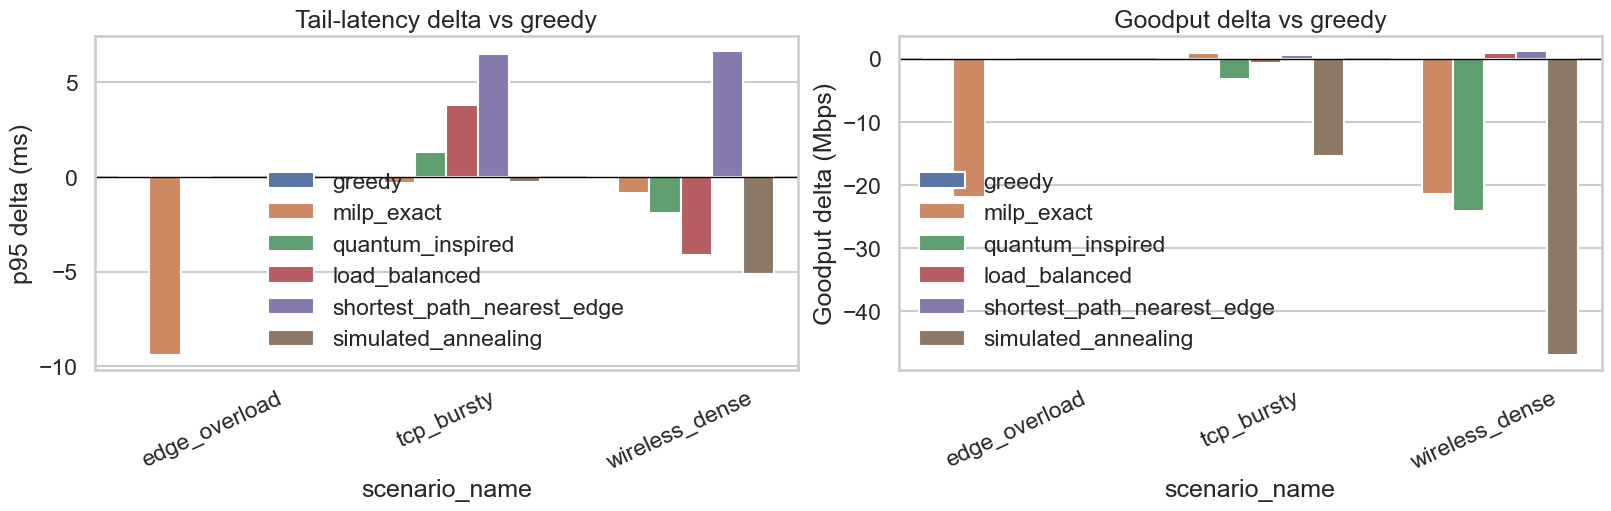

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)
sns.barplot(data=comparison, x='scenario_name', y='delta_p95_vs_greedy', hue='solver_name', ax=axes[0])
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title('Tail-latency delta vs greedy')
axes[0].set_ylabel('p95 delta (ms)')

sns.barplot(data=comparison, x='scenario_name', y='delta_goodput_vs_greedy', hue='solver_name', ax=axes[1])
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Goodput delta vs greedy')
axes[1].set_ylabel('Goodput delta (Mbps)')
for ax in axes:
    ax.tick_params(axis='x', rotation=25)
    ax.legend(title='', frameon=False)
plt.show()